In [13]:
import os
import sys
import re
import json
import logging
from pathlib import Path
from typing import Any, Dict, Optional

import joblib
import numpy as np
import pandas as pd
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import GroupShuffleSplit, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

# Tambahkan project root (parent dari src/) ke sys.path
_project_root = os.path.abspath(os.path.join(os.path.dirname(__file__), "..")) if "__file__" in dir() else os.path.abspath("..")
if _project_root not in sys.path:
    sys.path.insert(0, _project_root)

from src.dataset import load_samples, parse_class_dir_map
from src.features import FeatureConfig, extract_dataset_features, extract_video_features, load_features_csv
from src.utils import ensure_dir, setup_logging

print("Library berhasil di-import.")

Library berhasil di-import.


In [14]:
class Config:
    # Dataset yang dipakai: sdfvd2.0 (di dalamnya ada folder real/ dan not_real/)
    dataset_root = os.path.join(_project_root, "data", "sdfvd2.0")
    labels_csv = None 
    
    # Output directory untuk menyimpan model dan hasil
    out_dir = os.path.join(_project_root, "outputs", "train_versi_ipynb")
    
    # Mapping folder: "label_di_csv=nama_folder_fisik"
    class_dir_map = "real=real,not_real=not_real"

    # --- Cache ---
    reuse_features = True
    ignore_saved_config = False

    # --- Feature ---
    frame_stride = 1
    fps_sample = None
    max_frames = 10000
    img_size = 256
    
    denoise = True
    lbp_points = 16
    lbp_radius = 2
    lbp_method = "uniform"
    
    face_crop = True
    face_margin = 0.25
    grid_size = 2
    include_std = True

    # --- Split ---
    split_mode = "random"  
    test_size = 0.2
    random_state = 42
    stratify = False

    # --- Extra Features ---
    use_frames_used = False

    # --- SVM Params ---
    svm_kernel = "linear"
    C = 10.0
    gamma = "scale"
    degree = 3
    class_weight = "balanced"

args = Config()

# Setup Output Directory & Logging
out_dir = ensure_dir(Path(args.out_dir).expanduser().resolve())
setup_logging(out_dir=out_dir, level=logging.INFO, log_name="train.log")
log = logging.getLogger("notebook_train")

print("=" * 55)
print("  KONFIGURASI TRAINING")
print("=" * 55)
print(f"  Dataset Root : {os.path.abspath(args.dataset_root)}")
print(f"  Output Dir   : {out_dir}")
print(f"  SVM Kernel   : {args.svm_kernel}")
print(f"  C            : {args.C}")
print(f"  Gamma        : {args.gamma}")
print(f"  Class Weight : {args.class_weight}")
print(f"  Split Mode   : {args.split_mode} (test={args.test_size})")
print(f"  Reuse Feat.  : {args.reuse_features}")
print("-" * 55)
print(f"  LBP          : P={args.lbp_points}, R={args.lbp_radius}, method={args.lbp_method}")
print(f"  Image Size   : {args.img_size}")
print(f"  Face Crop    : {args.face_crop} (margin={args.face_margin})")
print(f"  Grid Size    : {args.grid_size}")
print(f"  Denoise      : {args.denoise}")
print("=" * 55)

# Cek apakah folder data ada
if not os.path.exists(args.dataset_root):
    print(f"\n⚠ PERINGATAN: Folder dataset TIDAK DITEMUKAN!")
    print(f"  Path    : {args.dataset_root}")
    print(f"  CWD     : {os.getcwd()}")
    print("  Pastikan folder 'data/sdfvd2.0' ada dan berisi video.")
else:
    items = os.listdir(args.dataset_root)
    print(f"\n✓ Folder dataset ditemukan ({len(items)} item)")
    for item in items[:5]:
        print(f"  - {item}")

  KONFIGURASI TRAINING
  Dataset Root : c:\ai-video-lbp-svm\data\sdfvd2.0
  Output Dir   : C:\ai-video-lbp-svm\outputs\train_versi_ipynb
  SVM Kernel   : linear
  C            : 10.0
  Gamma        : scale
  Class Weight : balanced
  Split Mode   : random (test=0.2)
  Reuse Feat.  : True
-------------------------------------------------------
  LBP          : P=16, R=2, method=uniform
  Image Size   : 256
  Face Crop    : True (margin=0.25)
  Grid Size    : 2
  Denoise      : True

✓ Folder dataset ditemukan (2 item)
  - not_real
  - real


In [15]:
def _parse_gamma(gamma_str):
    try:
        return float(gamma_str)
    except (TypeError, ValueError):
        return gamma_str

def base_group_id(video_path: str) -> str:
    """Group id untuk mencegah data leakage antar augmentasi video yang sama."""
    stem = Path(video_path).stem.lower()
    stem = re.sub(r"^(real_|fake_)", "", stem)
    if "_aug_" in stem:
        stem = stem.split("_aug_", 1)[0]

    m = re.fullmatch(r"vs(\d+)", stem)
    if m:
        return m.group(1)
    m = re.fullmatch(r"v(\d+)", stem)
    if m:
        return m.group(1)
    return stem

def _load_saved_config_if_any(out_dir: Path, log: logging.Logger) -> Optional[FeatureConfig]:
    cfg_path = out_dir / "config.json"
    if not cfg_path.exists():
        return None
    try:
        d = json.loads(cfg_path.read_text(encoding="utf-8"))
        cfg = FeatureConfig.from_dict(d)
        log.info("Loaded saved feature config from %s", cfg_path)
        return cfg
    except Exception as e:
        log.warning("Failed to read saved config.json. Error: %s", e)
        return None

print("Helper functions defined.")

Helper functions defined.


In [16]:
dataset_root = Path(args.dataset_root).expanduser().resolve()
labels_csv = Path(args.labels_csv).expanduser().resolve() if args.labels_csv else None
class_dir_map = parse_class_dir_map(args.class_dir_map) if not labels_csv else {}

log.info("Loading samples from: %s", dataset_root)

# Memuat sample video
samples = load_samples(
    dataset_root=dataset_root,
    labels_csv=labels_csv,
    class_dir_map=class_dir_map if not labels_csv else None,
    logger=log,
)

if not samples:
    print("\n⚠ TIDAK ADA SAMPEL VIDEO DITEMUKAN!")
    print(f"  Ekspektasi struktur:")
    print(f"    {args.dataset_root}/real/*.mp4")
    print(f"    {args.dataset_root}/not_real/*.mp4")
    raise RuntimeError("No samples found.")

# Hitung distribusi label
from collections import Counter
label_counts = Counter(s.label for s in samples)

print("=" * 55)
print("  DATASET INFO")
print("=" * 55)
print(f"  Total Sampel : {len(samples)}")
for label, count in sorted(label_counts.items()):
    print(f"  - {label:10s}  : {count} video")
print("=" * 55)

2026-05-20 19:31:57 [INFO] notebook_train: Loading samples from: C:\ai-video-lbp-svm\data\sdfvd2.0
2026-05-20 19:31:57 [INFO] notebook_train: Class 'real' from folder 'C:\ai-video-lbp-svm\data\sdfvd2.0\real': 456 videos
2026-05-20 19:31:57 [INFO] notebook_train: Class 'not_real' from folder 'C:\ai-video-lbp-svm\data\sdfvd2.0\not_real': 471 videos
2026-05-20 19:31:57 [INFO] notebook_train: Loaded 927 samples total.


  DATASET INFO
  Total Sampel : 927
  - not_real    : 471 video
  - real        : 456 video


PREPROCESSING
  Video    : real_v10_aug_0.mp4
  Label    : real
  Frame ke : 54 / 109
  Resolusi : 378x720


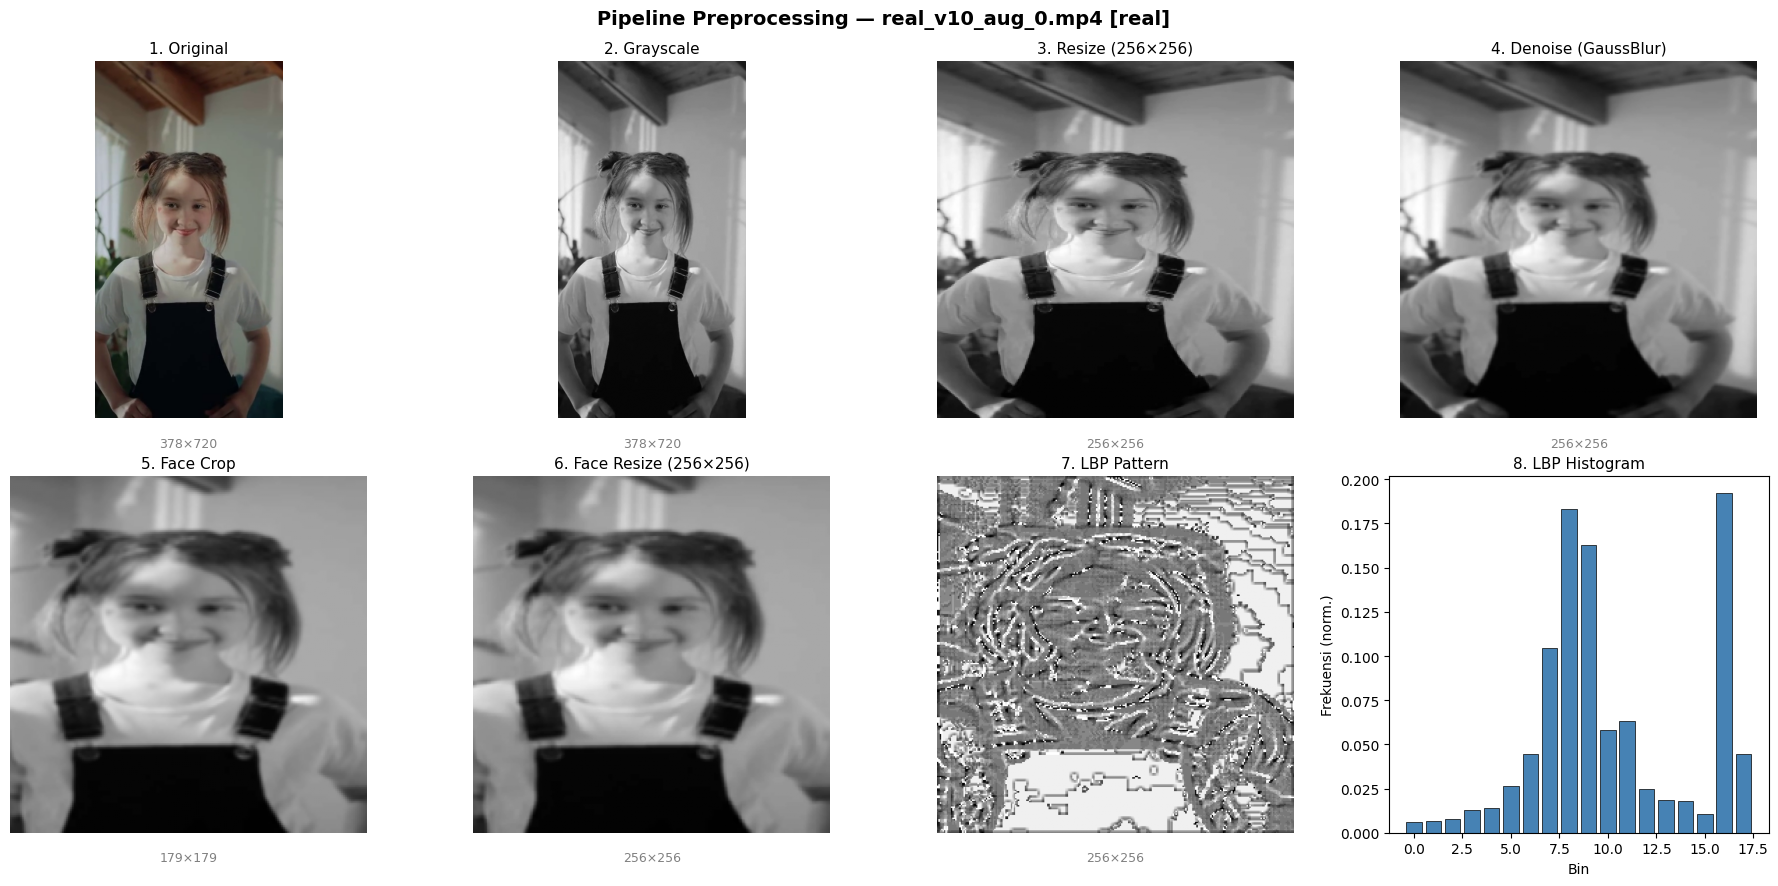


  Histogram LBP (18 bins):
  Min=0.005844  Max=0.192337  Sum=1.000000


In [17]:
# ============================================================
#  PREVIEW PREPROCESSING (1 video sampel)
# ============================================================
import cv2
import matplotlib.pyplot as plt
from skimage.feature import local_binary_pattern

# Ambil 1 sampel video
sample_video = samples[0]
cap = cv2.VideoCapture(str(sample_video.path))

# Baca 1 frame dari tengah video
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
mid_frame = total_frames // 2
cap.set(cv2.CAP_PROP_POS_FRAMES, mid_frame)
ret, frame_bgr = cap.read()
cap.release()

if ret and frame_bgr is not None:
    print("=" * 55)
    print("PREPROCESSING")
    print("=" * 55)
    print(f"  Video    : {Path(sample_video.path).name}")
    print(f"  Label    : {sample_video.label}")
    print(f"  Frame ke : {mid_frame} / {total_frames}")
    print(f"  Resolusi : {frame_bgr.shape[1]}x{frame_bgr.shape[0]}")
    print("=" * 55)

    # --- Step 1: Original (RGB) ---
    frame_rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)

    # --- Step 2: Grayscale ---
    gray = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2GRAY)

    # --- Step 3: Resize ---
    img_size = args.img_size
    gray_resized = cv2.resize(gray, (img_size, img_size), interpolation=cv2.INTER_AREA)

    # --- Step 4: Denoise (Gaussian Blur) ---
    if args.denoise:
        gray_denoised = cv2.GaussianBlur(gray_resized, (3, 3), 0)
    else:
        gray_denoised = gray_resized.copy()

    # --- Step 5: Face Crop ---
    from src.features import crop_face_or_center
    face_cropped = crop_face_or_center(gray_denoised, margin=args.face_margin)
    face_resized = cv2.resize(face_cropped, (img_size, img_size), interpolation=cv2.INTER_AREA)

    # --- Step 6: LBP ---
    lbp_img = local_binary_pattern(face_resized, args.lbp_points, args.lbp_radius, method=args.lbp_method)

    # --- Step 7: LBP Histogram ---
    n_bins = args.lbp_points + 2  # uniform method
    lbp_hist, _ = np.histogram(lbp_img.ravel(), bins=n_bins, range=(0, n_bins))
    lbp_hist = lbp_hist.astype(np.float32)
    lbp_hist /= (lbp_hist.sum() + 1e-8)

    # --- Plot semua tahap ---
    fig, axes = plt.subplots(2, 4, figsize=(18, 9))
    fig.suptitle(f"Pipeline Preprocessing — {Path(sample_video.path).name} [{sample_video.label}]",
                 fontsize=14, fontweight="bold")

    steps = [
        (frame_rgb,      "1. Original",           None),
        (gray,           "2. Grayscale",           "gray"),
        (gray_resized,   f"3. Resize ({img_size}×{img_size})", "gray"),
        (gray_denoised,  "4. Denoise (GaussBlur)", "gray"),
        (face_cropped,   "5. Face Crop",           "gray"),
        (face_resized,   f"6. Face Resize ({img_size}×{img_size})", "gray"),
        (lbp_img,        "7. LBP Pattern",         "gray"),
    ]

    for idx, (img, title, cmap) in enumerate(steps):
        ax = axes[idx // 4][idx % 4]
        ax.imshow(img, cmap=cmap)
        ax.set_title(title, fontsize=11)
        ax.axis("off")
        h, w = img.shape[:2]
        ax.text(0.5, -0.08, f"{w}×{h}", transform=ax.transAxes, ha="center", fontsize=9, color="gray")

    # Histogram LBP di subplot terakhir
    ax_hist = axes[1][3]
    ax_hist.bar(range(n_bins), lbp_hist, color="steelblue", edgecolor="black", linewidth=0.5)
    ax_hist.set_title("8. LBP Histogram", fontsize=11)
    ax_hist.set_xlabel("Bin")
    ax_hist.set_ylabel("Frekuensi (norm.)")

    plt.tight_layout()
    plt.show()

    print(f"\n  Histogram LBP ({n_bins} bins):")
    print(f"  Min={lbp_hist.min():.6f}  Max={lbp_hist.max():.6f}  Sum={lbp_hist.sum():.6f}")
else:
    print("  ⚠ Gagal membaca frame dari video sampel.")

In [18]:
features_csv = out_dir / "features.csv"
saved_cfg = None

# Cek apakah bisa reuse config lama
if args.reuse_features and features_csv.exists() and (not args.ignore_saved_config):
    saved_cfg = _load_saved_config_if_any(out_dir, log)

if saved_cfg is not None:
    cfg = saved_cfg
else:
    cfg = FeatureConfig(
        img_size=args.img_size,
        denoise=bool(args.denoise),
        lbp_points=args.lbp_points,
        lbp_radius=args.lbp_radius,
        lbp_method=args.lbp_method,
        frame_stride=args.frame_stride,
        fps_sample=args.fps_sample,
        max_frames=args.max_frames,
        face_crop=bool(args.face_crop),
        face_margin=float(args.face_margin),
        grid_size=int(args.grid_size),
        include_std=bool(args.include_std),
    )

log.info("Using feature config: %s", cfg.to_dict())

print("=" * 55)
print("  EKSTRAKSI FITUR")
print("=" * 55)

if args.reuse_features and features_csv.exists():
    log.info("Reusing features file: %s", features_csv)
    print(f"  ✓ Menggunakan fitur CACHED")
    print(f"    File: {features_csv}")
else:
    log.info("Extracting features -> %s", features_csv)
    print("  ⏳ Mulai ekstraksi fitur (mungkin memakan waktu)...")
    extract_dataset_features(samples, cfg, features_csv, logger_=log)
    (out_dir / "config.json").write_text(json.dumps(cfg.to_dict(), indent=2), encoding="utf-8")
    print("  ✓ Ekstraksi fitur selesai!")

# Preview fitur
_df_preview = pd.read_csv(features_csv)
_feat_cols = [c for c in _df_preview.columns if c.startswith("feat_")]
_n_samples = len(_df_preview)
_n_feats = len(_feat_cols)

print("-" * 55)
print(f"  Jumlah Sampel  : {_n_samples}")
print(f"  Jumlah Fitur   : {_n_feats}")
print(f"  Kolom Metadata : video_path, label, frames_used")

# Statistik fitur
_feat_data = _df_preview[_feat_cols]
print("\n  Statistik Fitur (ringkasan):")
print(f"  {'':>12} {'Min':>12} {'Max':>12} {'Mean':>12} {'Std':>12}")
print(f"  {'-'*12} {'-'*12} {'-'*12} {'-'*12} {'-'*12}")
print(f"  {'Semua feat':<12} {_feat_data.min().min():>12.6f} {_feat_data.max().max():>12.6f} {_feat_data.values.mean():>12.6f} {_feat_data.values.std():>12.6f}")

# Statistik per label
for lbl in sorted(_df_preview["label"].unique()):
    _sub = _df_preview[_df_preview["label"] == lbl][_feat_cols]
    print(f"  {lbl:<12} {_sub.min().min():>12.6f} {_sub.max().max():>12.6f} {_sub.values.mean():>12.6f} {_sub.values.std():>12.6f}")

# Preview beberapa baris
print(f"\n  Preview 5 sampel pertama:")
print(f"  {'No':<4} {'Video':<35} {'Label':<10} {'Frames':>6} {'feat_0':>10} {'feat_1':>10} {'feat_2':>10}")
print(f"  {'-'*4} {'-'*35} {'-'*10} {'-'*6} {'-'*10} {'-'*10} {'-'*10}")
for i, row in _df_preview.head(5).iterrows():
    vname = Path(row["video_path"]).stem
    if len(vname) > 33:
        vname = vname[:30] + "..."
    print(f"  {i+1:<4} {vname:<35} {row['label']:<10} {int(row['frames_used']):>6} {row['feat_0']:>10.6f} {row['feat_1']:>10.6f} {row['feat_2']:>10.6f}")

print("=" * 55)

2026-05-20 19:31:58 [INFO] notebook_train: Loaded saved feature config from C:\ai-video-lbp-svm\outputs\train_versi_ipynb\config.json
2026-05-20 19:31:58 [INFO] notebook_train: Using feature config: {'img_size': 256, 'denoise': True, 'lbp_points': 16, 'lbp_radius': 2, 'lbp_method': 'uniform', 'frame_stride': 1, 'fps_sample': None, 'max_frames': 10000, 'face_crop': True, 'face_margin': 0.25, 'grid_size': 2, 'include_std': True}
2026-05-20 19:31:58 [INFO] notebook_train: Reusing features file: C:\ai-video-lbp-svm\outputs\train_versi_ipynb\features.csv


  EKSTRAKSI FITUR
  ✓ Menggunakan fitur CACHED
    File: C:\ai-video-lbp-svm\outputs\train_versi_ipynb\features.csv
-------------------------------------------------------
  Jumlah Sampel  : 927
  Jumlah Fitur   : 144
  Kolom Metadata : video_path, label, frames_used

  Statistik Fitur (ringkasan):
                        Min          Max         Mean          Std
  ------------ ------------ ------------ ------------ ------------
  Semua feat       0.000170     0.534726     0.031688     0.051267
  not_real         0.000170     0.526181     0.031757     0.051418
  real             0.000178     0.534726     0.031617     0.051111

  Preview 5 sampel pertama:
  No   Video                               Label      Frames     feat_0     feat_1     feat_2
  ---- ----------------------------------- ---------- ------ ---------- ---------- ----------
  1    real_v10_aug_0                      real          109   0.008673   0.010103   0.014042
  2    real_v10_aug_1                      real       

In [19]:
# Load feature matrix
df, X, y, input_cols = load_features_csv(features_csv, use_frames_used=bool(args.use_frames_used))
log.info("Training inputs: use_frames_used=%s | n_samples=%d | n_features=%d",
         args.use_frames_used, X.shape[0], X.shape[1])

# Split Logic
if args.split_mode == "group":
    groups = np.array([base_group_id(vp) for vp in df["video_path"].tolist()])
    gss = GroupShuffleSplit(n_splits=1, test_size=float(args.test_size), random_state=int(args.random_state))
    train_idx, test_idx = next(gss.split(X, y, groups=groups))
    log.info("Split mode=group: train=%d test=%d", len(train_idx), len(test_idx))
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]
    test_df = df.iloc[test_idx].copy()
    split_info = "Group (No data leakage)"
else:
    strat = y if args.stratify else None
    idx_all = np.arange(len(y))
    X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
        X, y, idx_all,
        test_size=float(args.test_size),
        random_state=int(args.random_state),
        stratify=strat,
    )
    log.info("Split mode=random%s: train=%d test=%d",
             " (stratified)" if args.stratify else " (non-stratified)",
             len(y_train), len(y_test))
    test_df = df.iloc[idx_test].copy()
    split_info = f"Random{' (stratified)' if args.stratify else ''}"

from collections import Counter
train_dist = Counter(y_train)
test_dist = Counter(y_test)

print("=" * 55)
print("  DATA SPLIT")
print("=" * 55)
print(f"  Total Sampel : {X.shape[0]}")
print(f"  Fitur Dim    : {X.shape[1]}")
print(f"  Split Mode   : {split_info}")
print("-" * 55)
print(f"  {'Set':<10} {'Total':>7} {'real':>8} {'not_real':>10}")
print(f"  {'-'*10} {'-'*7} {'-'*8} {'-'*10}")
print(f"  {'Train':<10} {len(y_train):>7} {train_dist.get('real',0):>8} {train_dist.get('not_real',0):>10}")
print(f"  {'Test':<10} {len(y_test):>7} {test_dist.get('real',0):>8} {test_dist.get('not_real',0):>10}")
print("=" * 55)

2026-05-20 19:31:58 [INFO] notebook_train: Training inputs: use_frames_used=False | n_samples=927 | n_features=144
2026-05-20 19:31:58 [INFO] notebook_train: Split mode=random (non-stratified): train=741 test=186


  DATA SPLIT
  Total Sampel : 927
  Fitur Dim    : 144
  Split Mode   : Random
-------------------------------------------------------
  Set          Total     real   not_real
  ---------- ------- -------- ----------
  Train          741      356        385
  Test           186      100         86


In [20]:
# --- Training SVM ---
class_weight_val = None if args.class_weight == "none" else "balanced"
gamma_val = _parse_gamma(args.gamma)

svm = SVC(
    kernel=args.svm_kernel,
    C=float(args.C),
    gamma=gamma_val,
    degree=int(args.degree),
    probability=True,
    class_weight=class_weight_val,
    random_state=int(args.random_state),
)

model = Pipeline([("scaler", StandardScaler()), ("svm", svm)])

log.info(
    "Training SVM: kernel=%s, C=%.4f, gamma=%s, class_weight=%s",
    args.svm_kernel, args.C, str(gamma_val), str(class_weight_val)
)

print("=" * 55)
print("  TRAINING SVM")
print("=" * 55)
print(f"  Kernel       : {args.svm_kernel}")
print(f"  C            : {args.C}")
print(f"  Gamma        : {gamma_val}")
print(f"  Class Weight : {class_weight_val}")
print("-" * 55)
print("  Sedang Train...")

model.fit(X_train, y_train)

print("  Training selesai!")
print("=" * 55)

2026-05-20 19:31:58 [INFO] notebook_train: Training SVM: kernel=linear, C=10.0000, gamma=scale, class_weight=balanced


  TRAINING SVM
  Kernel       : linear
  C            : 10.0
  Gamma        : scale
  Class Weight : balanced
-------------------------------------------------------
  Sedang Train...
  Training selesai!


In [25]:
# Prediksi & Evaluasi
y_pred = model.predict(X_test)
report = classification_report(y_test, y_pred, digits=4, output_dict=True)
report_str = classification_report(y_test, y_pred, digits=4)

log.info("Classification report:\n%s", report_str)

accuracy = report["accuracy"]

print("=" * 55)
print("  CLASSIFICATION REPORT")
print("=" * 55)

# Metrics per class
print(f"\n  {'Metrik':<15} {'Precision':>10} {'Recall':>10} {'F1-Score':>10} {'Support':>10}")
print(f"  {'-'*15} {'-'*10} {'-'*10} {'-'*10} {'-'*10}")
for label in ["real", "not_real"]:
    r = report[label]
    print(f"  {label:<15} {r['precision']:>10.4f} {r['recall']:>10.4f} {r['f1-score']:>10.4f} {int(r['support']):>10}")

print(f"  {'-'*15} {'-'*10} {'-'*10} {'-'*10} {'-'*10}")
print(f"  {'Accuracy':<15} {'':>10} {'':>10} {accuracy:>10.4f} {int(report['weighted avg']['support']):>10}")

print("\n" + "=" * 55)

IndentationError: unindent does not match any outer indentation level (<tokenize>, line 76)

In [22]:
# Save bundle (termasuk config dan input columns untuk keperluan predict nanti)
bundle: Dict[str, Any] = {
    "model": model,
    "feature_config": cfg.to_dict(),
    "input_columns": input_cols,
    "split": {
        "split_mode": args.split_mode,
        "test_size": float(args.test_size),
        "random_state": int(args.random_state),
        "stratify": bool(args.stratify),
        "use_frames_used": bool(args.use_frames_used),
    },
    "svm_params": {
        "kernel": args.svm_kernel,
        "C": float(args.C),
        "gamma": gamma_val,
        "degree": int(args.degree),
        "class_weight": class_weight_val,
    },
}

model_path = out_dir / "model.joblib"
joblib.dump(bundle, model_path)

# Save test predictions dengan probability
print("=" * 55)
print("  Simpan model dan hasil prediksi")
print("=" * 55)

if hasattr(model, "predict_proba"):
    probs = model.predict_proba(X_test)
    cls = list(getattr(model, "classes_", ["real", "not_real"]))
    prob_map = {c: probs[:, i] for i, c in enumerate(cls)}

    test_df["y_true"] = y_test
    test_df["y_pred"] = y_pred
    if "not_real" in prob_map:
        test_df["prob_not_real"] = prob_map["not_real"]
    
    pred_path = out_dir / "test_predictions.csv"
    test_df.to_csv(pred_path, index=False)
    print(f"  Hasil prediksi data uji : {pred_path}")

print(f"  Hasil model       : {model_path}")
print("=" * 55)
print("\n  Semua file tersimpan.")

  Simpan model dan hasil prediksi
  Hasil prediksi data uji : C:\ai-video-lbp-svm\outputs\train_versi_ipynb\test_predictions.csv
  Hasil model       : C:\ai-video-lbp-svm\outputs\train_versi_ipynb\model.joblib

  Semua file tersimpan.


In [23]:
# ============================================================
#  PREDIKSI VIDEO BARU (data/video_tes)
# ============================================================
import time

test_video_dir = Path(os.path.join(_project_root, "data", "video_tes"))
video_extensions = {".mp4", ".avi", ".mov", ".mkv", ".webm", ".flv"}

# Cari semua video di folder
test_videos = sorted([
    f for f in test_video_dir.iterdir()
    if f.is_file() and f.suffix.lower() in video_extensions
])

print("=" * 70)
print("  PREDIKSI VIDEO BARU")
print("=" * 70)
print(f"  Folder   : {test_video_dir}")
print(f"  Jumlah   : {len(test_videos)} video")
print("=" * 70)

if not test_videos:
    print("\n  ⚠ Tidak ada video ditemukan di folder tersebut.")
else:
    results = []

    for i, vpath in enumerate(test_videos, 1):
        print(f"\n  [{i}/{len(test_videos)}] Memproses: {vpath.name}")
        t0 = time.time()

        # Ekstraksi fitur
        feat_vec, frames_used = extract_video_features(vpath, cfg, logger_=log)
        elapsed = time.time() - t0

        if feat_vec is None:
            print(f"    ⚠ Gagal mengekstraksi fitur (skip)")
            results.append({
                "video": vpath.name,
                "prediksi": "ERROR",
                "confidence": 0.0,
                "prob_real": 0.0,
                "prob_not_real": 0.0,
                "frames": 0,
                "waktu": elapsed,
            })
            continue

        # Reshape untuk prediksi
        X_new = feat_vec.reshape(1, -1)

        # Prediksi
        pred_label = model.predict(X_new)[0]
        pred_proba = model.predict_proba(X_new)[0]
        cls_labels = list(model.classes_)
        prob_dict = {cls_labels[j]: pred_proba[j] for j in range(len(cls_labels))}

        confidence = max(pred_proba) * 100

        results.append({
            "video": vpath.name,
            "prediksi": pred_label,
            "confidence": confidence,
            "prob_real": prob_dict.get("real", 0.0) * 100,
            "prob_not_real": prob_dict.get("not_real", 0.0) * 100,
            "frames": frames_used,
            "waktu": elapsed,
        })

        status = "✓ REAL" if pred_label == "real" else "✗ NOT REAL (Deepfake)"
        print(f"    Hasil      : {status}")
        print(f"    Confidence : {confidence:.2f}%")
        print(f"    Frames     : {frames_used}")
        print(f"    Waktu      : {elapsed:.2f}s")

    # --- Tabel Ringkasan ---
    print("\n" + "=" * 70)
    print("  RINGKASAN HASIL PREDIKSI")
    print("=" * 70)
    print(f"  {'No':<4} {'Video':<35} {'Prediksi':<12} {'Conf.':>7} {'P(real)':>8} {'P(fake)':>8} {'Frame':>6} {'Waktu':>6}")
    print(f"  {'-'*4} {'-'*35} {'-'*12} {'-'*7} {'-'*8} {'-'*8} {'-'*6} {'-'*6}")

    for i, r in enumerate(results, 1):
        vname = r["video"]
        if len(vname) > 33:
            vname = vname[:30] + "..."
        print(f"  {i:<4} {vname:<35} {r['prediksi']:<12} {r['confidence']:>6.2f}% {r['prob_real']:>7.2f}% {r['prob_not_real']:>7.2f}% {r['frames']:>6} {r['waktu']:>5.2f}s")

    # Statistik
    total = len(results)
    real_count = sum(1 for r in results if r["prediksi"] == "real")
    fake_count = sum(1 for r in results if r["prediksi"] == "not_real")
    error_count = sum(1 for r in results if r["prediksi"] == "ERROR")
    avg_conf = np.mean([r["confidence"] for r in results if r["prediksi"] != "ERROR"])
    total_time = sum(r["waktu"] for r in results)

    print(f"  {'-'*4} {'-'*35} {'-'*12} {'-'*7} {'-'*8} {'-'*8} {'-'*6} {'-'*6}")
    print(f"\n  Total Video   : {total}")
    print(f"  Real          : {real_count}")
    print(f"  Not Real      : {fake_count}")
    if error_count > 0:
        print(f"  Error         : {error_count}")
    print(f"  Avg Confidence: {avg_conf:.2f}%")
    print(f"  Total Waktu   : {total_time:.2f}s")
    print("=" * 70)

  PREDIKSI VIDEO BARU
  Folder   : c:\ai-video-lbp-svm\data\video_tes
  Jumlah   : 40 video

  [1/40] Memproses: video_10_not_real.mp4
    Hasil      : ✗ NOT REAL (Deepfake)
    Confidence : 55.93%
    Frames     : 127
    Waktu      : 2.50s

  [2/40] Memproses: video_10_real.mp4
    Hasil      : ✗ NOT REAL (Deepfake)
    Confidence : 54.55%
    Frames     : 94
    Waktu      : 1.98s

  [3/40] Memproses: video_11_not_real.mp4
    Hasil      : ✓ REAL
    Confidence : 51.18%
    Frames     : 171
    Waktu      : 3.26s

  [4/40] Memproses: video_11_real.mp4
    Hasil      : ✗ NOT REAL (Deepfake)
    Confidence : 55.67%
    Frames     : 94
    Waktu      : 1.98s

  [5/40] Memproses: video_12_not_real.mp4
    Hasil      : ✗ NOT REAL (Deepfake)
    Confidence : 55.57%
    Frames     : 171
    Waktu      : 3.24s

  [6/40] Memproses: video_12_real.mp4
    Hasil      : ✗ NOT REAL (Deepfake)
    Confidence : 54.12%
    Frames     : 94
    Waktu      : 1.95s

  [7/40] Memproses: video_13_not_real

Confusion Matrix (rows=true, cols=pred):
          real  not_real
real        82        18
not_real    17        69
Confusion matrix saved: C:\ai-video-lbp-svm\outputs\train_versi_ipynb\confusion_matrix.png


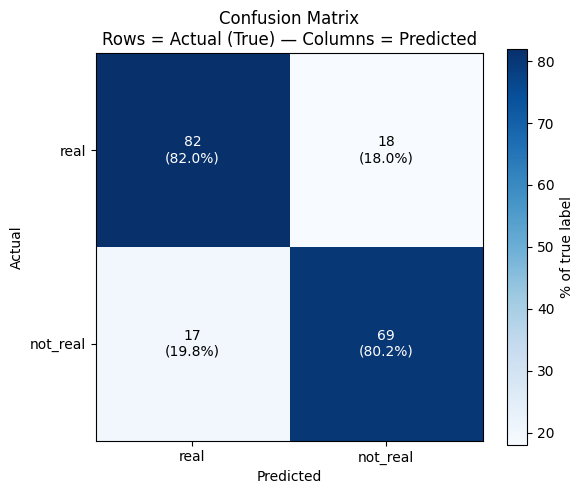

In [32]:
# --- Confusion Matrix (robust) ---
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix

# Coba import seaborn, tapi fallback ke matplotlib jika tidak tersedia
try:
    import seaborn as sns
    has_seaborn = True
except Exception:
    has_seaborn = False

# Pastikan sel prediksi sudah dijalankan sehingga variabel y_test dan y_pred ada
try:
    cm = confusion_matrix(y_test, y_pred, labels=["real", "not_real"])
except NameError:
    raise NameError("y_test atau y_pred tidak ditemukan. Jalankan sel Prediksi terlebih dahulu.")

labels = ["real", "not_real"]
cm_df = pd.DataFrame(cm, index=labels, columns=labels)
print("Confusion Matrix (rows=true, cols=pred):")
print(cm_df)

# Persentase per baris (true label) dan annotasi count + %
cm_perc = cm.astype('float') / cm.sum(axis=1)[:, None] * 100
annot = np.empty_like(cm).astype(object)
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        annot[i, j] = f"{cm[i, j]}\n({cm_perc[i, j]:.1f}%)"

if has_seaborn:
    plt.figure(figsize=(6,5))
    sns.heatmap(cm_perc, annot=annot, fmt='', cmap='Blues', xticklabels=labels, yticklabels=labels, cbar_kws={'label':'% of true label'})
    plt.title('Confusion Matrix\nRows = Actual (True) — Columns = Predicted')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
else:
    fig, ax = plt.subplots(figsize=(6,5))
    im = ax.imshow(cm_perc, interpolation='nearest', cmap='Blues')
    ax.set_xticks(np.arange(len(labels)))
    ax.set_xticklabels(labels)
    ax.set_yticks(np.arange(len(labels)))
    ax.set_yticklabels(labels)
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            # gunakan warna teks yang kontras berdasarkan nilai persentase
            txt_color = 'white' if cm_perc[i,j] > 50 else 'black'
            ax.text(j, i, annot[i, j], ha='center', va='center', color=txt_color)
    plt.title('Confusion Matrix\nRows = Actual (True) — Columns = Predicted')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.colorbar(im, label='% of true label')

plt.tight_layout()
fig_path = out_dir / 'confusion_matrix.png'
plt.gcf().savefig(fig_path)
print(f'Confusion matrix saved: {fig_path}')
plt.show()